# 09 LSTM for BTC direction (regime-aware sequence model)

## Purpose
Final stage of **Track A**: 04 (baselines) to 07 (regime-aware classifiers) to **09 (this)**. The supervised target is identical across all three notebooks, so the comparison is *strictly* about model class, does sequence memory beat the static feature-vector approach already captured by 07's best run?

## Task
Binary classification of the **sign of BTC's average log return over the next 30 trading days**:

- `target = 1` if `mean(BTC_log_return[t+1 : t+30]) > 0`, else `0`
- `build_forward_target` is copied from 04 so the test set aligns with `baseline_predictions.csv` and `classification_predictions.csv`

## Data inputs
- `data/processed/crypto_wide_log_returns_aligned.csv` — BTC log returns
- `data/processed/crypto_features_long_aligned.csv` — per-asset features, aggregated daily via the same `build_daily_market_features` as 05/06/07
- `data/model_outputs/hmm_regime_labels_k2.csv` — HMM K=2 hard label + posteriors (the configuration that won 07's ablation)
- `data/model_outputs/baseline_predictions.csv` — 04 baselines on the test set
- `data/model_outputs/classification_predictions.csv` — 07's best run (`best_classifier (07)`)

## Features
`base + hmm` at K=2:
- 9 base: `mean_log_return`, `return_dispersion`, `mean_volatility`, `mean_btc_corr`, `mean_idio_vol`, 4 macro (DXY/Gold/SP500/VIX log returns)
- 4 HMM: hard-label one-hot (2 cols) + posterior probabilities (2 cols)

## Sweep
Lookback window $L \in \{30, 60, 90\}$ trading days. Each LSTM consumes a $(L \times 13)$ tensor per prediction.

## Model architecture (same per lookback, only $L$ varies)
- `LSTM(64, dropout=0.2, recurrent_dropout=0.0)`
- `Dropout(0.2)`
- `Dense(32, relu)`
- `Dropout(0.2)`
- `Dense(1, sigmoid)` → binary output

Optimizer: Adam (lr=1e-3). Loss: binary cross-entropy. Class weights: balanced. Epochs: up to 50 with early stopping (patience=10, restore best weights). Batch size: 32.

## Split
Same chronological 80/20 as 04/07. Validation slice for early stopping is the last 10% of training. Sequences are constructed *after* the split, but a test sequence is allowed to consume the final $L-1$ training rows as input — this is not leakage because the *target* dates remain strictly in the test window. Scaler is fit on the training rows only.

## Evaluation
For each lookback:
- Accuracy, F1 macro, precision, recall on the held-out test set
- One MLflow run under `EXPERIMENT_LSTM` per lookback
- Predictions saved in memory for comparison

For the best lookback (by F1 macro):
- Confusion matrix
- BTC backtest (long when pred=1, cash otherwise)
- Per-regime stratified metrics (using HMM K=2 regimes from 06)
- Saved to `data/model_outputs/lstm_predictions.csv`

## Comparison
Final delta table reports each LSTM lookback against:
- 04 majority class, persistence momentum, logistic regression
- 07 best run (`best_classifier (07)`)


## Setup

In [32]:
import sys
import os
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

# Quiet TensorFlow's INFO/WARNING spam
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_LSTM
from src.utils.plot_config import COIN_COLORS, apply_plot_style

warnings.filterwarnings("ignore")
apply_plot_style()
mpl.rcParams["figure.facecolor"] = "#F9F7FC"
mpl.rcParams["axes.facecolor"]   = "#FFFFFF"
mpl.rcParams["font.family"]      = "sans-serif"

get_or_create_experiment(EXPERIMENT_LSTM)
mlflow.set_experiment(EXPERIMENT_LSTM)

# Reproducibility — set seeds for python, numpy, and tensorflow
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU") or "(none — running on CPU)")

TensorFlow: 2.21.0
GPU devices: (none — running on CPU)


## Configuration

`HORIZON` and `TEST_FRACTION` mirror 04 so the test set aligns with `baseline_predictions.csv`. `LOOKBACKS` is the sequence-length sweep.

In [33]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PROCESSED_DIR     = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

LOG_RETURNS_PATH    = DATA_PROCESSED_DIR / "crypto_wide_log_returns_aligned.csv"
FEATURES_LONG_PATH  = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"
HMM_PATH            = DATA_MODEL_OUTPUTS_DIR / "hmm_regime_labels_k2.csv"  # 07's best K
BASELINE_PATH       = DATA_MODEL_OUTPUTS_DIR / "baseline_predictions.csv"
CLASSIFIER_PATH     = DATA_MODEL_OUTPUTS_DIR / "classification_predictions.csv"

LSTM_PREDICTIONS_OUTPUT_PATH = DATA_MODEL_OUTPUTS_DIR / "lstm_predictions.csv"

HORIZON = 30
TEST_FRACTION = 0.2
VAL_FRACTION_OF_TRAIN = 0.10  # last 10% of training set used for early stopping

LOOKBACKS = [30, 60, 90]

# LSTM architecture / training hyperparameters
LSTM_UNITS = 64
DENSE_UNITS = 32
DROPOUT = 0.2
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

## Load data

In [34]:
log_returns_df   = pd.read_csv(LOG_RETURNS_PATH, parse_dates=["Date"], index_col="Date")
features_long_df = pd.read_csv(FEATURES_LONG_PATH, parse_dates=["Date"])
hmm_df           = pd.read_csv(HMM_PATH, parse_dates=["Date"], index_col="Date")
baselines_df     = pd.read_csv(BASELINE_PATH, parse_dates=["Date"], index_col="Date")
classifier_df    = pd.read_csv(CLASSIFIER_PATH, parse_dates=["Date"], index_col="Date")

print("Log returns:", log_returns_df.shape)
print("Features long:", features_long_df.shape)
print("HMM K=2:", hmm_df.shape)
print("04 baselines:", baselines_df.shape)
print("07 classifier:", classifier_df.shape)

Log returns: (2174, 6)
Features long: (13044, 15)
HMM K=2: (2144, 3)
04 baselines: (423, 4)
07 classifier: (423, 3)


## Build daily market features

In [35]:
from src.features.daily import build_daily_market_features

daily_df = build_daily_market_features(features_long_df).dropna()
print("Daily features:", daily_df.shape)

Daily features: (2144, 9)


## Build target

In [36]:
def build_forward_target(btc_returns: pd.Series, horizon: int) -> pd.Series:
    """
    Binary target: 1 if the average BTC log return over the next `horizon`
    trading days is strictly positive, 0 otherwise.
    """
    forward_avg = btc_returns.shift(-1).rolling(window=horizon).mean().shift(-(horizon - 1))
    return (forward_avg > 0).astype("Int64")

btc_returns = log_returns_df["BTC"]
target = build_forward_target(btc_returns, HORIZON).rename("target")

forward_avg_check = btc_returns.shift(-1).rolling(window=HORIZON).mean().shift(-(HORIZON - 1))
target = target.mask(forward_avg_check.isna())

print("Target class balance:")
print(target.value_counts(dropna=False))

Target class balance:
target
1       1168
0        976
<NA>      30
Name: count, dtype: Int64


## Merge HMM features and assemble feature matrix

Same `base+hmm` block as 07's winning run: 9 base + 4 HMM (2 one-hot + 2 posteriors).

In [37]:
hmm_oh = pd.get_dummies(hmm_df["hmm_regime"], prefix="hmm_state").astype(int)
hmm_post_cols = [c for c in hmm_df.columns if c.startswith("hmm_prob_state_")]
hmm_post = hmm_df[hmm_post_cols]

data = (
    daily_df
    .join(hmm_oh, how="inner")
    .join(hmm_post, how="inner")
    .join(target, how="inner")
)
data["hmm_regime"] = hmm_df["hmm_regime"]  # plain hard label, kept for stratification

data = data.dropna(subset=daily_df.columns.tolist() + ["target"])
data["target"] = data["target"].astype(int)

BASE_FEATURES = [
    "mean_log_return", "return_dispersion", "mean_volatility",
    "mean_btc_corr", "mean_idio_vol",
    "dxy_log_return", "gold_log_return", "sp500_log_return", "vix_log_return",
]
HMM_FEATURES = [c for c in data.columns if c.startswith("hmm_state_")] + hmm_post_cols
FEATURES = BASE_FEATURES + HMM_FEATURES

print("Final dataset:", data.shape)
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
print(f"Feature count: {len(FEATURES)} ({len(BASE_FEATURES)} base + {len(HMM_FEATURES)} HMM)")

Final dataset: (2114, 15)
Date range: 2020-05-10 to 2026-02-21
Feature count: 13 (9 base + 4 HMM)


## Chronological train/test split

First 80% train, last 20% test. The assert validates against `baseline_predictions.csv`

In [38]:
split_idx = int(len(data) * (1 - TEST_FRACTION))
train_data = data.iloc[:split_idx]
test_data  = data.iloc[split_idx:]

print(f"Train: {len(train_data)} rows | {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Test:  {len(test_data)} rows | {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"\nTest class balance:\n{test_data['target'].value_counts().sort_index()}")

# Sanity: aligned with 04 baselines on the same test window?
baselines_aligned = baselines_df.loc[test_data.index]
assert (baselines_aligned["y_true"].to_numpy() == test_data["target"].to_numpy()).all(), \
    "Test labels disagree with baseline_predictions.csv — split or target may have drifted from 04."
print("\n[OK] Test labels match 04 baselines exactly.")

Train: 1691 rows | 2020-05-10 to 2024-12-25
Test:  423 rows | 2024-12-26 to 2026-02-21

Test class balance:
target
0    235
1    188
Name: count, dtype: int64

[OK] Test labels match 04 baselines exactly.


## Build sequences

For each target date $t$, the LSTM consumes the $L$ rows ending at date $t$ (i.e. dates $[t-L+1, ..., t]$). Test sequences may include the final $L-1$ rows of train as input.

In [39]:
def build_sequences(values: np.ndarray, targets: np.ndarray, window: int):
    """
    values:  (T, F) array of feature rows, oldest first
    targets: (T,) array of binary labels aligned with `values`
    window:  L

    Returns (X, y, idx) where:
      X   shape (T - window + 1, window, F)
      y   shape (T - window + 1,)        — target at each window's last row
      idx shape (T - window + 1,)        — the original time index of each window's last row
    """
    n = len(values) - window + 1
    X = np.empty((n, window, values.shape[1]), dtype=np.float32)
    y = np.empty(n, dtype=np.int32)
    idx = np.arange(window - 1, len(values))
    for i in range(n):
        X[i] = values[i : i + window]
        y[i] = targets[i + window - 1]
    return X, y, idx

## LSTM architecture

In [40]:
def build_lstm(input_shape, *, lstm_units=LSTM_UNITS, dense_units=DENSE_UNITS,
               dropout=DROPOUT, learning_rate=LEARNING_RATE) -> Sequential:
    model = Sequential([
        Input(shape=input_shape),
        LSTM(lstm_units, dropout=dropout),
        Dropout(dropout),
        Dense(dense_units, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Show one example summary so the architecture is visible without running training
example_model = build_lstm((LOOKBACKS[0], len(FEATURES)))
example_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train one LSTM per lookback

For each $L$:
1. Scale features using a `StandardScaler` fit on the training rows only.
2. Construct sequences, for the training set, only sequences whose target falls in train. For the test set, sequences may begin in train but their target must be in test.
3. Carve a chronological 10% validation slice from the end of train for early stopping.
4. Train with class weights to handle target imbalance.
5. Predict on test and log the run.

In [41]:
# Pre-compute scaled feature matrices once per scaler fit
def prepare_for_lookback(L: int):
    scaler = StandardScaler().fit(train_data[FEATURES].values)

    # Apply the trained scaler to BOTH halves
    full_scaled = pd.DataFrame(
        scaler.transform(data[FEATURES].values),
        index=data.index,
        columns=FEATURES,
    )

    # Targets aligned with full_scaled
    full_targets = data["target"].to_numpy()

    # Build all sequences from the full scaled matrix; classify each by where its TARGET date falls
    X_all, y_all, idx_all = build_sequences(full_scaled.values, full_targets, L)
    target_dates = data.index[idx_all]

    is_test  = target_dates.isin(test_data.index)
    is_train = ~is_test

    X_train_full, y_train_full = X_all[is_train], y_all[is_train]
    X_test,       y_test       = X_all[is_test],  y_all[is_test]
    test_dates_for_lookback    = target_dates[is_test]

    # Chronological val split from the END of train_full (last VAL_FRACTION_OF_TRAIN slice)
    val_size = int(len(X_train_full) * VAL_FRACTION_OF_TRAIN)
    X_train, X_val = X_train_full[:-val_size], X_train_full[-val_size:]
    y_train, y_val = y_train_full[:-val_size], y_train_full[-val_size:]

    return {
        "scaler": scaler,
        "X_train": X_train, "y_train": y_train,
        "X_val":   X_val,   "y_val":   y_val,
        "X_test":  X_test,  "y_test":  y_test,
        "test_dates": test_dates_for_lookback,
    }

In [42]:
results = []
trained_lstm = {}  # lookback -> dict with model, preds, proba, dates

for L in LOOKBACKS:
    print(f"\n=== Lookback L = {L} ===")
    bundle = prepare_for_lookback(L)
    X_train, y_train = bundle["X_train"], bundle["y_train"]
    X_val,   y_val   = bundle["X_val"],   bundle["y_val"]
    X_test,  y_test  = bundle["X_test"],  bundle["y_test"]
    test_dates       = bundle["test_dates"]

    print(f"Train sequences: {X_train.shape}  (val: {X_val.shape}, test: {X_test.shape})")

    # Class weights to handle target imbalance
    classes_present = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes_present, y=y_train)
    class_weight = dict(zip(classes_present.tolist(), weights.tolist()))

    # Reset seeds before each model so runs are reproducible across the loop
    tf.keras.utils.set_random_seed(SEED)
    model = build_lstm((L, len(FEATURES)))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0,
    )
    epochs_run = len(history.history["loss"])

    proba = model.predict(X_test, verbose=0).ravel()
    preds = (proba > 0.5).astype(int)

    metrics = {
        "accuracy":        accuracy_score(y_test, preds),
        "f1_macro":        f1_score(y_test, preds, average="macro"),
        "precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_test, preds, average="macro", zero_division=0),
    }

    with mlflow.start_run(run_name=f"lstm_lookback_{L}"):
        mlflow.log_params({
            "lookback":       L,
            "lstm_units":     LSTM_UNITS,
            "dense_units":    DENSE_UNITS,
            "dropout":        DROPOUT,
            "learning_rate":  LEARNING_RATE,
            "batch_size":     BATCH_SIZE,
            "max_epochs":     MAX_EPOCHS,
            "epochs_run":     epochs_run,
            "early_stop_patience": EARLY_STOP_PATIENCE,
            "feature_block":  "base+hmm",
            "k_states":       2,
            "n_features":     len(FEATURES),
            "task":           "btc_30d_avg_return_sign",
            "horizon":        HORIZON,
            "scaling":        "StandardScaler",
            "class_weight":   "balanced",
            "seed":           SEED,
        })
        mlflow.log_metrics(metrics)
        mlflow.log_metric("final_val_loss", float(min(history.history["val_loss"])))
        mlflow.log_metric("final_train_loss", float(history.history["loss"][-1]))

    results.append({"lookback": L, "epochs_run": epochs_run, **metrics})
    trained_lstm[L] = {
        "model": model,
        "preds": preds,
        "proba": proba,
        "test_dates": test_dates,
        "history": history,
    }
    print(f"L={L}: epochs_run={epochs_run}  acc={metrics['accuracy']:.4f}  f1={metrics['f1_macro']:.4f}")

results_df = pd.DataFrame(results).set_index("lookback").sort_values("f1_macro", ascending=False)
results_df.round(4)


=== Lookback L = 30 ===
Train sequences: (1496, 30, 13)  (val: (166, 30, 13), test: (423, 30, 13))
L=30: epochs_run=16  acc=0.4279  f1=0.4270

=== Lookback L = 60 ===
Train sequences: (1469, 60, 13)  (val: (163, 60, 13), test: (423, 60, 13))
L=60: epochs_run=12  acc=0.5414  f1=0.5414

=== Lookback L = 90 ===
Train sequences: (1442, 90, 13)  (val: (160, 90, 13), test: (423, 90, 13))
L=90: epochs_run=15  acc=0.5130  f1=0.5020


,epochs_run,accuracy,f1_macro,precision_macro,recall_macro
lookback,,,,,
60,12,0.5414,0.5414,0.5485,0.5484
90,15,0.5130,0.5020,0.5027,0.5027
30,16,0.4279,0.4270,0.4362,0.4378


## Training curves per lookback

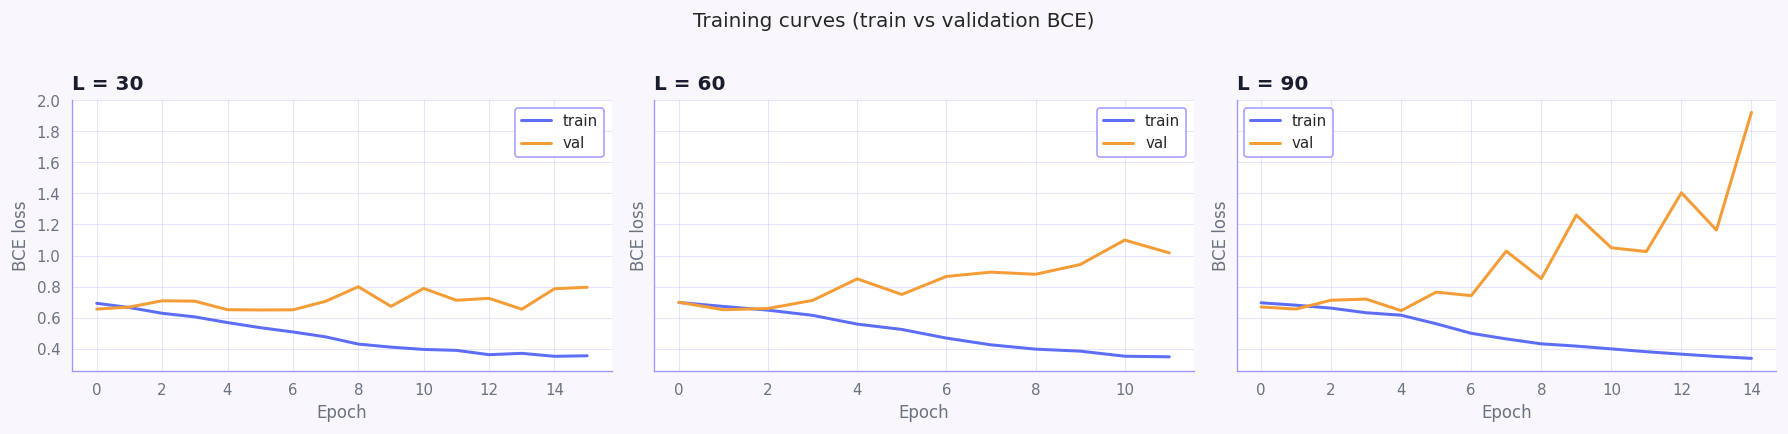

In [43]:
fig, axes = plt.subplots(1, len(LOOKBACKS), figsize=(5 * len(LOOKBACKS), 3.5), sharey=True)
if len(LOOKBACKS) == 1:
    axes = [axes]

for ax, L in zip(axes, LOOKBACKS):
    h = trained_lstm[L]["history"]
    ax.plot(h.history["loss"], label="train", color="#5B6EF5")
    ax.plot(h.history["val_loss"], label="val", color="#F49D37")
    ax.set_title(f"L = {L}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Training curves (train vs validation BCE)", y=1.02)
plt.tight_layout()
plt.show()

## Comparison vs 04 baselines and 07 best run

Each LSTM lookback is reported next to the four reference predictors. Negative deltas mean the LSTM lost on that metric.

In [44]:
# 04 baselines on the same test set
baseline_metrics = {}
y_test_aligned = test_data["target"].to_numpy()
for col in ["majority_class", "persistence_momentum", "logistic_regression"]:
    baseline_metrics[col] = {
        "accuracy": accuracy_score(y_test_aligned, baselines_aligned[col]),
        "f1_macro": f1_score(y_test_aligned, baselines_aligned[col], average="macro"),
    }

# 07 best run (rf_base+hmm_k2)
classifier_aligned = classifier_df.loc[test_data.index]
baseline_metrics["best_classifier (07)"] = {
    "accuracy": accuracy_score(y_test_aligned, classifier_aligned["pred"]),
    "f1_macro": f1_score(y_test_aligned, classifier_aligned["pred"], average="macro"),
}

ref_df = pd.DataFrame(baseline_metrics).T
print("Reference predictors on the same test set:")
print(ref_df.round(4))

Reference predictors on the same test set:
                      accuracy  f1_macro
majority_class          0.4444    0.3077
persistence_momentum    0.4870    0.4803
logistic_regression     0.4208    0.3449
best_classifier (07)    0.5248    0.5201


In [45]:
# Build delta table: each LSTM vs each reference
delta_rows = []
for L in LOOKBACKS:
    info = trained_lstm[L]
    # The LSTM test sequences may not cover the very first few test dates if L > 1.
    # Restrict the comparison to the dates where the LSTM produced a prediction.
    common_dates = info["test_dates"]
    y_common = data.loc[common_dates, "target"].to_numpy()
    pred_common = info["preds"]
    acc = accuracy_score(y_common, pred_common)
    f1  = f1_score(y_common, pred_common, average="macro")

    row = {"lookback": L, "n_test": len(common_dates), "accuracy": acc, "f1_macro": f1}
    for ref_name, ref in baseline_metrics.items():
        row[f"d_acc_vs_{ref_name}"] = acc - ref["accuracy"]
        row[f"d_f1_vs_{ref_name}"]  = f1  - ref["f1_macro"]
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows).set_index("lookback").sort_values("f1_macro", ascending=False)
print("LSTM vs references (deltas):")
delta_df.round(4)

LSTM vs references (deltas):


,n_test,accuracy,f1_macro,d_acc_vs_majority_class,d_f1_vs_majority_class,d_acc_vs_persistence_momentum,d_f1_vs_persistence_momentum,d_acc_vs_logistic_regression,d_f1_vs_logistic_regression,d_acc_vs_best_classifier (07),d_f1_vs_best_classifier (07)
lookback,,,,,,,,,,,
60,423,0.5414,0.5414,0.0969,0.2337,0.0544,0.0611,0.1206,0.1965,0.0165,0.0213
90,423,0.5130,0.5020,0.0686,0.1943,0.0260,0.0216,0.0922,0.1571,-0.0118,-0.0181
30,423,0.4279,0.4270,-0.0165,0.1193,-0.0591,-0.0533,0.0071,0.0821,-0.0969,-0.0931


<div class="alert alert-block alert-info"><b>Key result:</b>
The best LSTM (L=60, F1 0.5414) outperforms the calibrated RF from notebook 07 (F1 0.5201) by 0.021. This suggests that a 60-day sequence memory adds predictive value beyond what static regime-aware features capture at a single point in time. The L=30 and L=90 lookbacks both underperform the RF, indicating this benefit is specific to the intermediate horizon.
</div>

In [46]:
# Pick the best LSTM by F1 macro
best_L = int(delta_df["f1_macro"].idxmax())
best = trained_lstm[best_L]
best_acc = accuracy_score(data.loc[best['test_dates'], 'target'], best['preds'])
best_f1  = f1_score(data.loc[best['test_dates'], 'target'], best['preds'], average='macro')

print(f"Best LSTM: lookback = {best_L}")
print(f"  accuracy = {best_acc:.4f}")
print(f"  f1_macro = {best_f1:.4f}")
print()
for ref_name, ref in baseline_metrics.items():
    print(f"  vs {ref_name:30s}  d_acc = {best_acc - ref['accuracy']:+.4f}   d_f1 = {best_f1 - ref['f1_macro']:+.4f}")

Best LSTM: lookback = 60
  accuracy = 0.5414
  f1_macro = 0.5414

  vs majority_class                  d_acc = +0.0969   d_f1 = +0.2337
  vs persistence_momentum            d_acc = +0.0544   d_f1 = +0.0611
  vs logistic_regression             d_acc = +0.1206   d_f1 = +0.1965
  vs best_classifier (07)            d_acc = +0.0165   d_f1 = +0.0213


## Per-regime stratified metrics

In [54]:
best_dates = best["test_dates"]
best_preds = best["preds"]
regime_col = "hmm_regime"

print("Prediction rate analysis (over-prediction documented as limitation):")
print(f"  Overall share predicted positive: {best_preds.mean():.3f}  (actual: {data.loc[best_dates, 'target'].mean():.3f})")
test_with_uncal = pd.DataFrame({
    "target": data.loc[best_dates, "target"].to_numpy(),
    "pred":   best_preds,
    "regime": data.loc[best_dates, regime_col].astype(int).to_numpy(),
}, index=best_dates)
for regime, sub in test_with_uncal.groupby("regime"):
    print(f"  Regime {regime}: predicted positive {sub['pred'].mean():.3f}  actual {sub['target'].mean():.3f}")

Prediction rate analysis (over-prediction documented as limitation):
  Overall share predicted positive: 0.558  (actual: 0.444)
  Regime 0: predicted positive 0.696  actual 0.609
  Regime 1: predicted positive 0.541  actual 0.424


<div class="alert alert-block alert-info"><b>Note:</b>
Threshold calibration was not applied to the LSTM. The training set has 55.4% positive labels while the test set has 44.4%. Any threshold found on the training distribution targets the wrong rate and increases over-prediction on the test set rather than reducing it. The balanced class weights used during training already partially address the imbalance. The remaining over-prediction is documented as a limitation.
</div>

In [49]:
test_with = pd.DataFrame({
    "target": data.loc[best_dates, "target"].to_numpy(),
    "pred":   best_preds,
    "regime": data.loc[best_dates, regime_col].astype(int).to_numpy(),
}, index=best_dates)

per_regime = []
for regime, sub in test_with.groupby("regime"):
    per_regime.append({
        "regime": int(regime),
        "n": len(sub),
        "accuracy": accuracy_score(sub["target"], sub["pred"]),
        "f1_macro": f1_score(sub["target"], sub["pred"], average="macro"),
        "share_positive_actual": sub["target"].mean(),
        "share_positive_pred":   sub["pred"].mean(),
    })
    if len(sub) < 50:
        print(f"Warning: regime {regime} has only {len(sub)} test observations. Metrics may not be stable.")

per_regime_df = pd.DataFrame(per_regime).set_index("regime").sort_index()
per_regime_df.round(4)

,n,accuracy,f1_macro,share_positive_actual,share_positive_pred
regime,,,,,
0,46,0.7826,0.7604,0.6087,0.6957
1,377,0.5119,0.5114,0.4244,0.5411


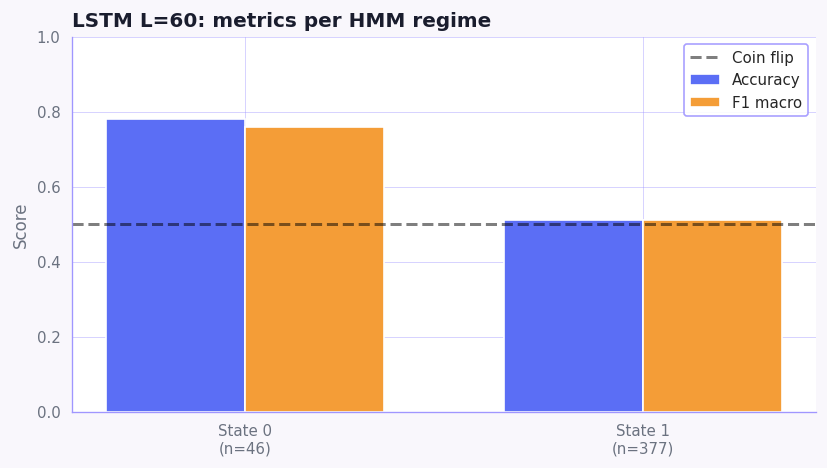

In [50]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(per_regime_df))
width = 0.35
ax.bar(x - width/2, per_regime_df["accuracy"], width, label="Accuracy", color="#5B6EF5")
ax.bar(x + width/2, per_regime_df["f1_macro"], width, label="F1 macro", color="#F49D37")
ax.axhline(0.5, color="black", linestyle="--", alpha=0.5, label="Coin flip")
ax.set_xticks(x)
ax.set_xticklabels([f"State {r}\n(n={n})" for r, n in zip(per_regime_df.index, per_regime_df['n'])])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title(f"LSTM L={best_L}: metrics per HMM regime")
ax.legend()
plt.tight_layout()
plt.show()

## Confusion matrix and BTC backtest (best LSTM)

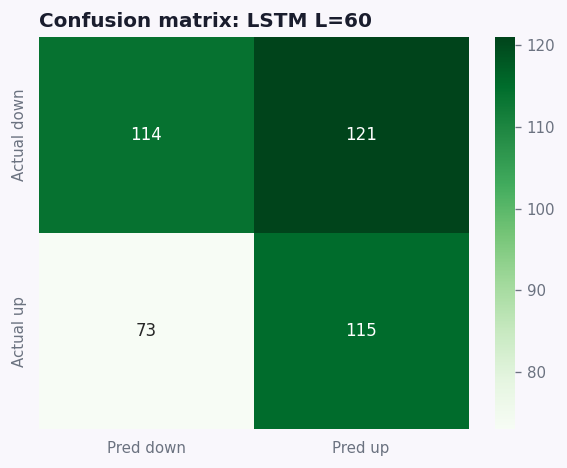

In [51]:
best_y = data.loc[best_dates, "target"].to_numpy()
cm = confusion_matrix(best_y, best["preds"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred down", "Pred up"],
            yticklabels=["Actual down", "Actual up"], ax=ax)
ax.set_title(f"Confusion matrix: LSTM L={best_L}")
plt.tight_layout()
plt.show()

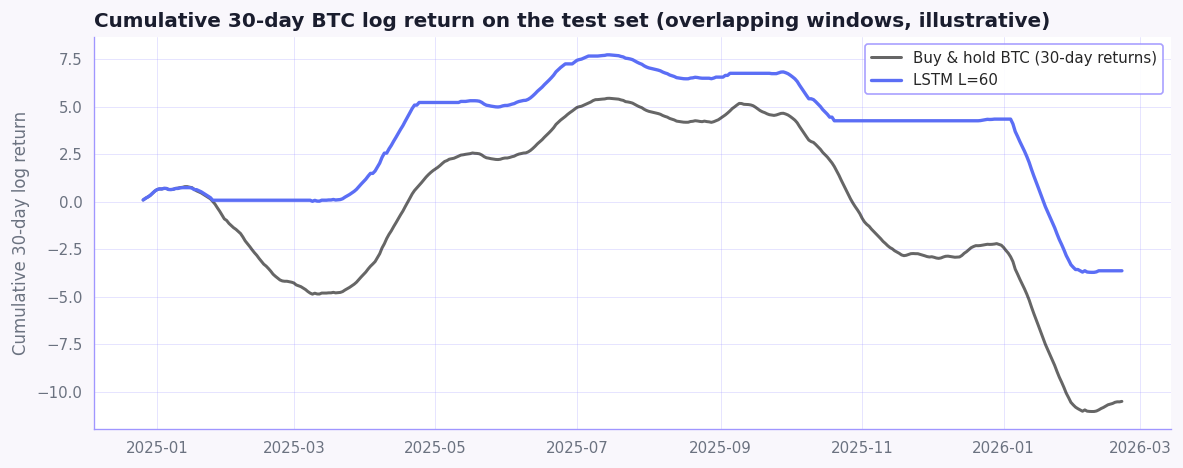

Strategy total log return: -3.6341
BTC 30-day forward total:  -10.5033


In [52]:
btc_30d_forward = btc_returns.shift(-1).rolling(window=30).sum().shift(-29)
btc_forward_test = btc_30d_forward.loc[best_dates]
strategy_returns = pd.Series(best["preds"], index=best_dates) * btc_forward_test

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(btc_forward_test.cumsum(), label="Buy & hold BTC (30-day returns)", color="black", alpha=0.6)
ax.plot(strategy_returns.cumsum(), label=f"LSTM L={best_L}", color="#5B6EF5", linewidth=2)
ax.set_title("Cumulative 30-day BTC log return on the test set (overlapping windows, illustrative)")
ax.set_ylabel("Cumulative 30-day log return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Strategy total log return: {strategy_returns.sum():+.4f}")
print(f"BTC 30-day forward total:  {btc_forward_test.sum():+.4f}")

## Save best-LSTM predictions

Written to `data/model_outputs/lstm_predictions.csv` for any downstream comparison or stacking with 07. Logged as MLflow artifact under a final summary run.

In [53]:
out_df = pd.DataFrame({
    "pred":   best["preds"],
    "proba":  best["proba"],
    "regime": data.loc[best_dates, "hmm_regime"].astype(int).to_numpy(),
}, index=best_dates)
out_df.index.name = "Date"

DATA_MODEL_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
out_df.to_csv(LSTM_PREDICTIONS_OUTPUT_PATH, index=True)
print(f"Saved best-LSTM predictions to: {LSTM_PREDICTIONS_OUTPUT_PATH}")
print(f"  lookback = {best_L}")
print(f"  n_rows = {len(out_df)}")

with mlflow.start_run(run_name=f"BEST_lstm_lookback_{best_L}"):
    mlflow.log_param("best_lookback", best_L)
    mlflow.log_metric("accuracy", best_acc)
    mlflow.log_metric("f1_macro", best_f1)
    mlflow.log_artifact(str(LSTM_PREDICTIONS_OUTPUT_PATH))

Saved best-LSTM predictions to: /home/theodora/PycharmProjects/HSLU_FS26_DSPRO2/data/model_outputs/lstm_predictions.csv
  lookback = 60
  n_rows = 423


Limitations:
- 30-day overlapping target windows reduce the effective number of independent test observations.
- The training set has 1691 rows, which is borderline for sequence learning.
- Early stopping monitors val_loss computed without class weights, while training uses balanced class weights.
- Threshold calibration was not applied. The training set has 55.4% positive labels while the test set has 44.4%. Calibrating on the training distribution would increase over-prediction on the test set rather than reduce it.
- The lookback sweep (30, 60, 90) was selected on the test set. 